In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from adjustText import adjust_text

In [2]:
route_graphs_test = Path("../results/test_graphs")
route_graphs_test.mkdir(parents=True, exist_ok=True)
route_graphs_train_val = Path("../results/train_val_graphs")
route_graphs_train_val.mkdir(parents=True, exist_ok=True)
print(route_graphs_test)
print(route_graphs_train_val)

../results/test_graphs
../results/train_val_graphs


In [3]:
test_results = pd.read_csv("benchmark_results.csv")
test_results

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Parameters_M,GFLOPs,Model_Size_MB,Training_Time_Seconds
0,ResNet18,92.307692,92.976190,86.079545,85.803167,11.180616,1.823526,42.730479,67.559321
1,ResNet34,92.307692,89.123377,88.825758,87.923743,21.288776,3.678232,81.351665,67.453247
2,ResNet50,90.769231,90.277778,83.252165,82.715998,23.524424,4.131711,90.052487,113.384481
3,ResNet101,92.307692,88.151042,90.165043,87.390110,42.516552,7.864404,162.807292,163.726815
4,MobileNetV2,81.538462,68.597973,65.165043,63.711081,2.234120,0.326217,8.767772,72.368061
5,MobileNetV3 Small,73.846154,56.585149,65.584416,56.906524,1.526056,0.061462,5.960000,31.458744
6,MobileNetV3 Large,93.846154,89.502165,86.079545,86.040626,4.212280,0.233569,16.278279,79.058012
7,EfficientNet B0,90.769231,79.473039,78.043831,78.687093,4.017796,0.413875,15.627084,102.807498
8,EfficientNet B1,84.615385,74.650097,64.502165,65.755495,6.523432,0.609345,25.319028,158.940738
9,EfficientNet B2,93.846154,91.973039,87.121212,86.821251,7.712266,0.700530,29.874387,227.667061


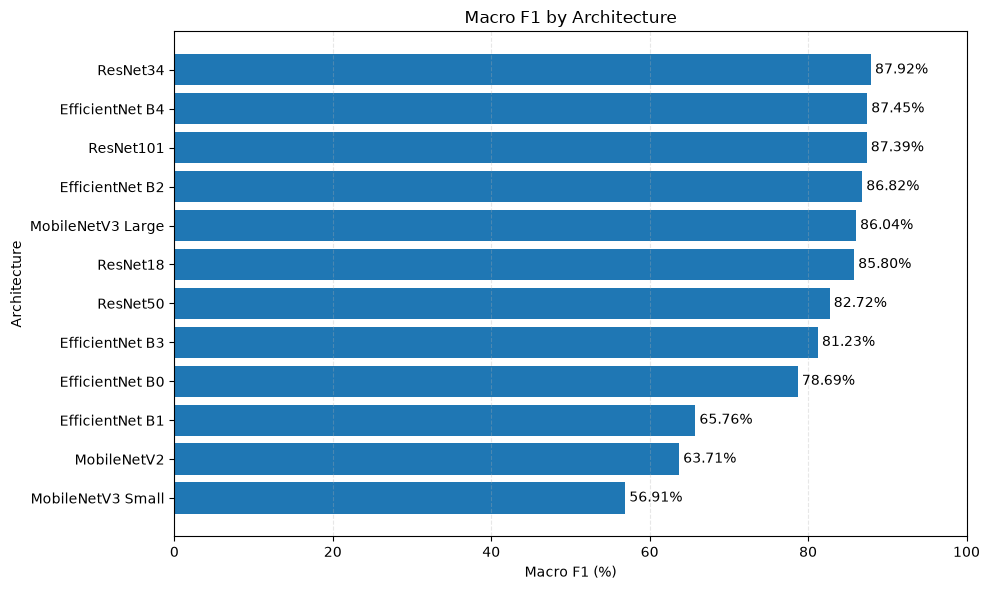

In [4]:
test_results_sorted = test_results.sort_values("Macro_F1")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(test_results_sorted["Model"], test_results_sorted["Macro_F1"])
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.set_title("Macro F1 by Architecture")
ax.set_xlabel("Macro F1 (%)")
ax.set_ylabel("Architecture")
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(route_graphs_test / "macro_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

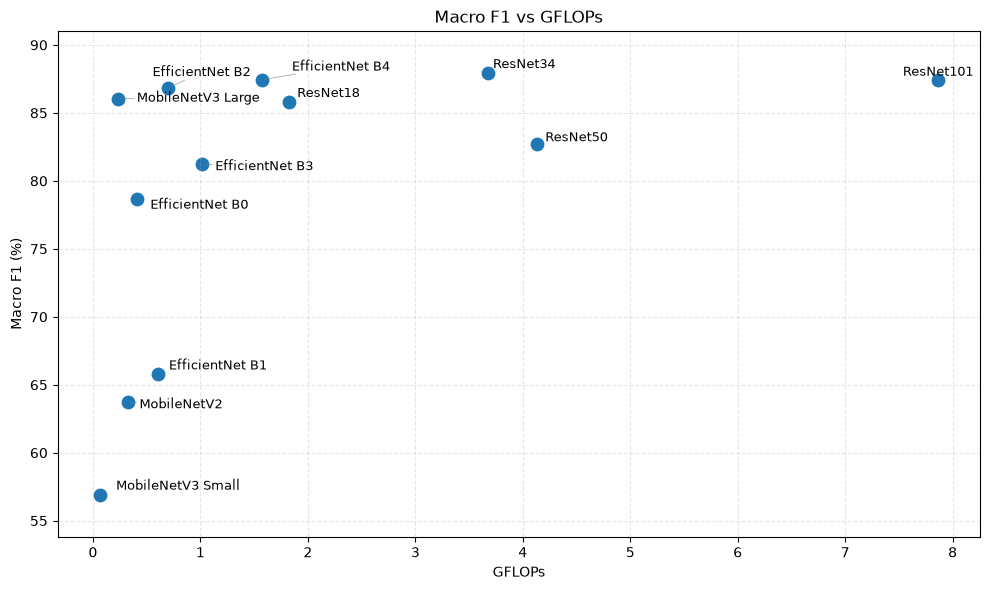

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(test_results["GFLOPs"], test_results["Macro_F1"], s=80)

texts = []
for _, row in test_results.iterrows():
    texts.append(ax.text(row["GFLOPs"], row["Macro_F1"], row["Model"], fontsize=9))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.8))

f1_range = test_results["Macro_F1"].max() - test_results["Macro_F1"].min()
margin = f1_range * 0.10

ax.set_title("Macro F1 vs GFLOPs")
ax.set_xlabel("GFLOPs")
ax.set_ylabel("Macro F1 (%)")
ax.set_ylim(test_results["Macro_F1"].min() - margin, test_results["Macro_F1"].max() + margin)
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(route_graphs_test / "f1_vs_gflops.png", dpi=300, bbox_inches="tight")
plt.show()

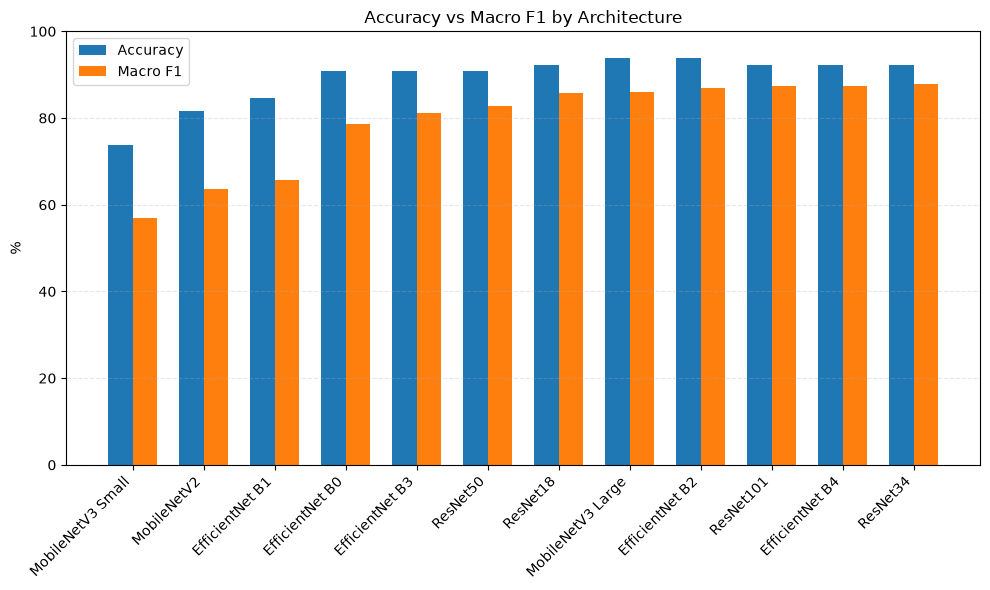

In [6]:
test_results_sorted = test_results.sort_values("Macro_F1")

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(test_results_sorted))
width = 0.35

ax.bar([i - width/2 for i in x], test_results_sorted["Accuracy"], width, label="Accuracy")
ax.bar([i + width/2 for i in x], test_results_sorted["Macro_F1"], width, label="Macro F1")

ax.set_xticks(x)
ax.set_xticklabels(test_results_sorted["Model"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_title("Accuracy vs Macro F1 by Architecture")
ax.set_ylabel("%")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(route_graphs_test / "accuracy_vs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

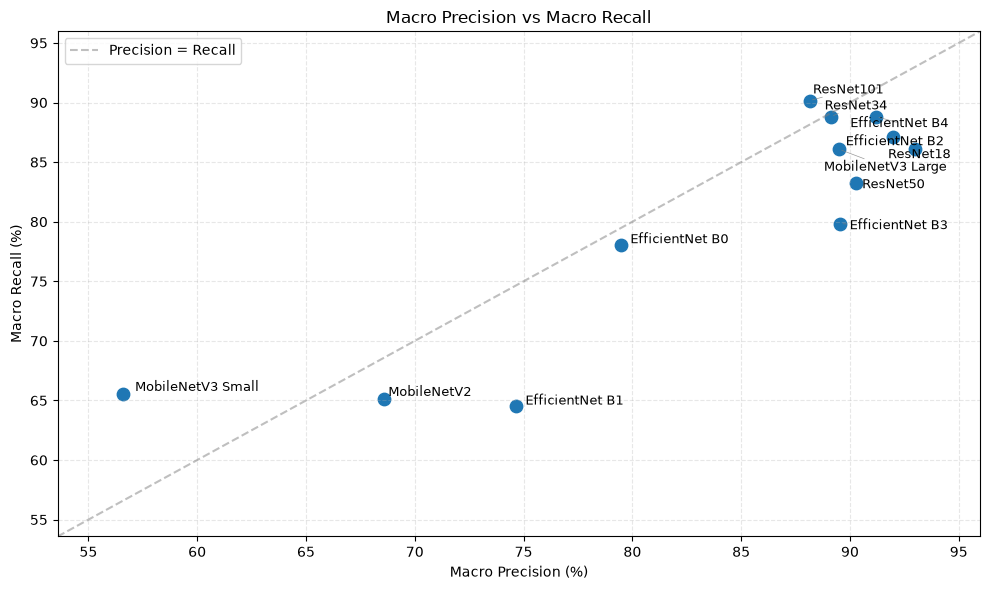

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(test_results["Macro_Precision"], test_results["Macro_Recall"], s=80)

texts = []
for _, row in test_results.iterrows():
    texts.append(ax.text(row["Macro_Precision"], row["Macro_Recall"], row["Model"], fontsize=9))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.8))

lims = [
    test_results[["Macro_Precision", "Macro_Recall"]].min().min() - 3,
    test_results[["Macro_Precision", "Macro_Recall"]].max().max() + 3
]
ax.plot(lims, lims, linestyle="--", color="gray", alpha=0.5, label="Precision = Recall")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Macro Precision vs Macro Recall")
ax.set_xlabel("Macro Precision (%)")
ax.set_ylabel("Macro Recall (%)")
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig(route_graphs_test / "precision_vs_recall.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
train_val_results = pd.read_csv("train_val_results.csv")
train_val_results

,Model,Best_Epoch,Train_Loss,Train_Accuracy,Train_Macro_Precision,Train_Macro_Recall,Train_Macro_F1,Val_Loss,Val_Accuracy,Val_Macro_Precision,Val_Macro_Recall,Val_Macro_F1
0,ResNet18,24,0.519855,99.807692,99.807692,99.907407,99.856632,0.682948,95.588235,96.819853,89.166667,91.933316
1,ResNet34,14,0.527797,98.653846,98.009898,98.157534,98.082490,0.639438,95.588235,95.119048,90.833333,92.340686
2,ResNet50,19,0.532955,99.038462,98.861059,98.946501,98.901184,0.726188,91.176471,87.708333,83.095238,83.623188
3,ResNet101,18,0.524682,98.461538,98.732353,98.122996,98.420895,0.612666,94.117647,94.375000,89.047619,90.298562
4,MobileNetV2,22,0.795979,89.038462,90.032953,85.132591,87.158413,0.852788,86.764706,80.902778,74.383117,74.959588
5,MobileNetV3 Small,13,0.947601,85.769231,88.617055,80.354483,81.488891,1.271172,70.588235,49.541095,58.360390,52.291667
6,MobileNetV3 Large,31,0.590414,98.269231,98.347614,98.347973,98.340054,0.768515,91.176471,85.037879,84.502165,84.668446
7,EfficientNet B0,29,0.649144,96.730769,96.764141,95.547423,96.121938,0.726412,91.176471,92.696268,80.000000,83.324176
8,EfficientNet B1,32,0.784813,91.346154,89.945312,88.670317,89.167532,0.750289,94.117647,92.642045,90.454545,90.004984
9,EfficientNet B2,31,0.528371,99.230769,99.115783,99.115783,99.115783,0.630654,95.588235,94.721639,92.500000,91.709037


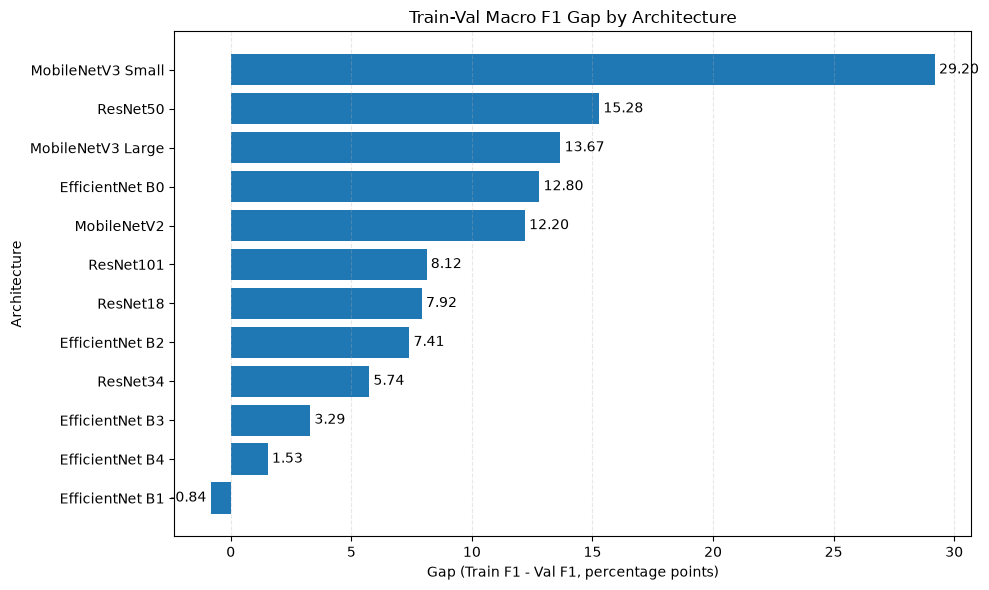

In [9]:
train_val_results["F1_Gap"] = train_val_results["Train_Macro_F1"] - train_val_results["Val_Macro_F1"]
gap_sorted = train_val_results.sort_values("F1_Gap")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(gap_sorted["Model"], gap_sorted["F1_Gap"])
ax.bar_label(bars, fmt="%.2f", padding=3)

ax.set_title("Train-Val Macro F1 Gap by Architecture")
ax.set_xlabel("Gap (Train F1 - Val F1, percentage points)")
ax.set_ylabel("Architecture")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(route_graphs_train_val / "train_val_gap.png", dpi=300, bbox_inches="tight")
plt.show()

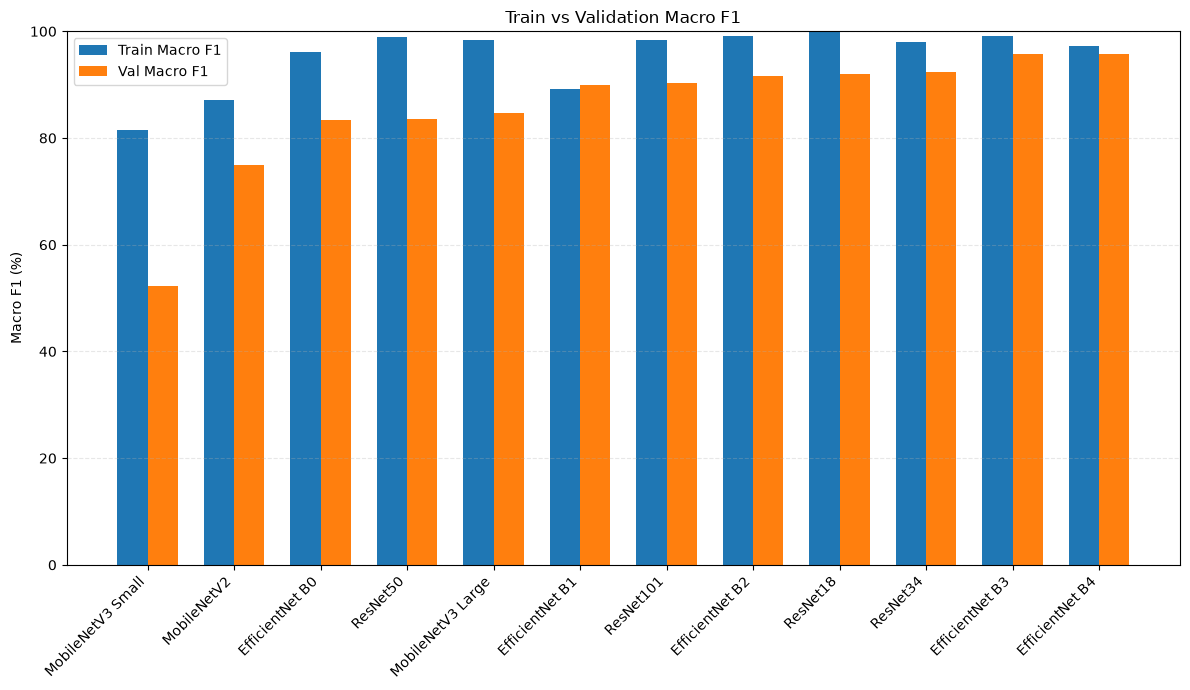

In [10]:
tv_sorted = train_val_results.sort_values("Val_Macro_F1")

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(tv_sorted))
width = 0.35

ax.bar([i - width/2 for i in x], tv_sorted["Train_Macro_F1"], width, label="Train Macro F1")
ax.bar([i + width/2 for i in x], tv_sorted["Val_Macro_F1"], width, label="Val Macro F1")

ax.set_xticks(x)
ax.set_xticklabels(tv_sorted["Model"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_title("Train vs Validation Macro F1")
ax.set_ylabel("Macro F1 (%)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(route_graphs_train_val / "train_vs_val_f1.png", dpi=300, bbox_inches="tight")
plt.show()

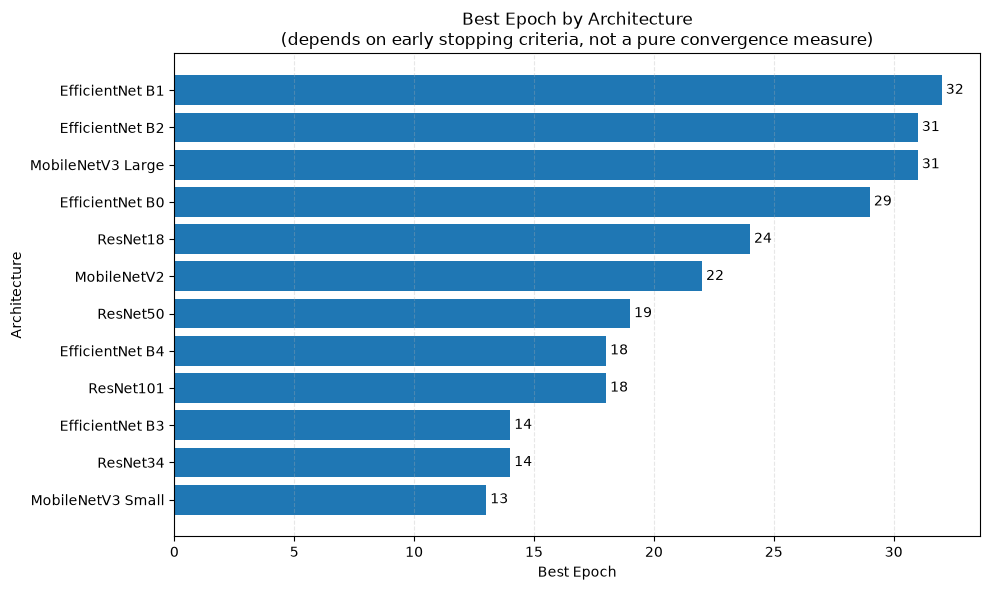

In [11]:
train_val_sorted = train_val_results.sort_values("Best_Epoch")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(train_val_sorted["Model"], train_val_sorted["Best_Epoch"])
ax.bar_label(bars, fmt="%.0f", padding=3)

ax.set_title("Best Epoch by Architecture\n(depends on early stopping criteria, not a pure convergence measure)")
ax.set_xlabel("Best Epoch")
ax.set_ylabel("Architecture")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(route_graphs_train_val / "best_epoch_by_architecture.png", dpi=300, bbox_inches="tight")
plt.show()

In [2]:
test_images = pd.read_csv("parametros_modelos.csv")
test_images

,Model,Weight decay,Backbone LR,Classifier LR,T_max
0,ResNet18,0.0001,0.00003,0.0003,25
1,ResNet34,0.0001,0.00003,0.0003,25
2,ResNet50,0.0001,0.00003,0.0003,25
3,ResNet101,0.0001,0.00003,0.0003,25
4,MobileNetV2,0.0001,0.00003,0.0003,25
5,MobileNetV3 Large,0.0001,0.00003,0.0003,25
6,MobileNetV3 Small,0.0001,0.00003,0.0003,25
7,EfficientNet B0,0.0001,0.00003,0.0001,35
8,EfficientNet B1,0.0001,0.00003,0.0003,25
9,EfficientNet B2,0.0001,0.00005,0.0003,35
